# 05 - Modelagem: Clustering de Setores Censitários (Censo 2022 BA)

Pipeline de aprendizado não supervisionado em dois estágios:

1. **UMAP** reduz as 11 features de proporção para 2D preservando estrutura local
2. **HDBSCAN** clusteriza os setores no espaço 2D

Por que não clusterizar diretamente em 11D?
- Em alta dimensão o HDBSCAN deixa ~89% dos setores como ruído
- UMAP comprime a topologia do espaço de features em regiões de densidade claras
- Resultado: de 89% de ruído para < 1%, cobrindo quase todos os setores

As features são proporções de **tipo de endereço** (`COD_ESPECIE`) por setor;
não existe label oficial para "qual é o perfil desse setor". O algoritmo descobre.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import silhouette_score
import hdbscan
import umap
from pathlib import Path

OUTPUT_DIR = Path('../outputs')

df = pd.read_parquet(OUTPUT_DIR / 'setores_features.parquet')

FEATURES = [
    'prop_domicilio_particular', 'prop_domicilio_coletivo',
    'prop_estab_agropecuario', 'prop_estab_ensino', 'prop_estab_saude',
    'prop_estab_outras', 'prop_construcao', 'prop_estab_religioso',
    'prop_finalidade_residencial', 'prop_finalidade_comercial', 'prop_finalidade_mista'
]

X = df[FEATURES].values
print(f'Setores: {len(df):,} | Features: {X.shape[1]}')

Setores: 30,355 | Features: 11


/home/wesleiferreira/Documentos/GitHub/trabalho-topicos-4/.venv/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


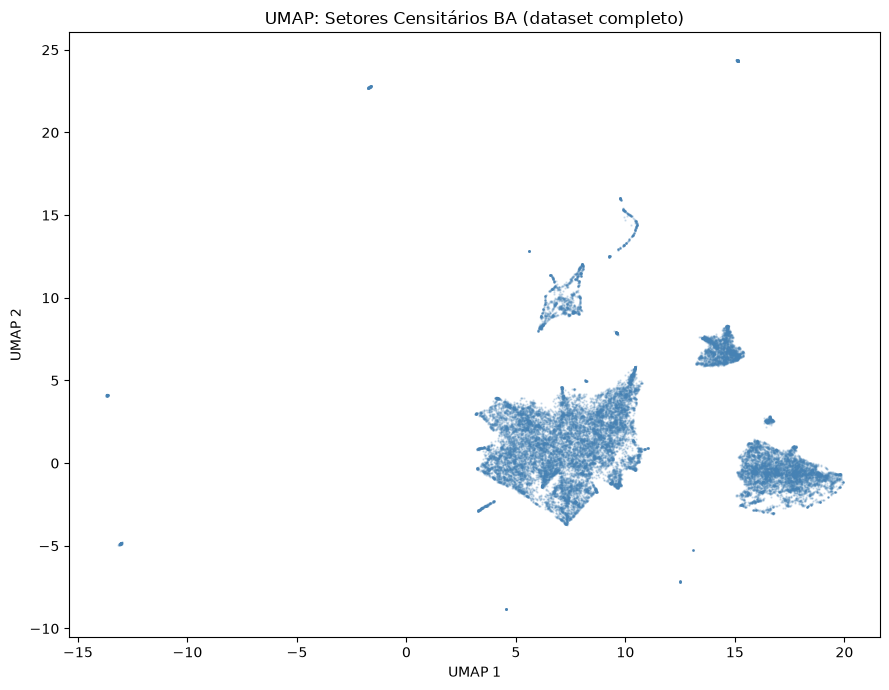

In [2]:
# UMAP no dataset COMPLETO (não só 15k), usado para clustering e visualização
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,   # vizinhança maior preserva estrutura global
    min_dist=0.0,     # pontos próximos ficam mais compactos → melhor para HDBSCAN
    random_state=42
)
X_umap = reducer.fit_transform(X)
df['umap_x'] = X_umap[:, 0]
df['umap_y'] = X_umap[:, 1]

plt.figure(figsize=(9, 7))
plt.scatter(df['umap_x'], df['umap_y'], s=0.5, alpha=0.2, c='steelblue')
plt.title('UMAP: Setores Censitários BA (dataset completo)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/umap_setores.png', dpi=150)
plt.show()

In [3]:
# HDBSCAN no espaço 2D do UMAP
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)
labels = clusterer.fit_predict(X_umap)
df['cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
print(f'Clusters encontrados : {n_clusters}')
print(f'Ruído (-1)           : {n_noise:,} ({n_noise/len(df)*100:.1f}%)')
print()
print(df['cluster'].value_counts().sort_index())

# Comparativo 11D vs UMAP para justificar a escolha
print()
print('─' * 50)
cl_11d = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=3,
                          cluster_selection_method='eom')
labs_11d = cl_11d.fit_predict(X)
n_11d = len(set(labs_11d)) - (1 if -1 in labs_11d else 0)
r_11d = (labs_11d == -1).mean() * 100
print(f'{"":30} {"11D direto":>10} {"UMAP→HDBSCAN":>13}')
print('─' * 50)
print(f'{"Clusters encontrados":30} {n_11d:>10} {n_clusters:>13}')
print(f'{"Ruído (%)":30} {r_11d:>9.1f}% {n_noise/len(df)*100:>12.1f}%')
print('─' * 50)

Clusters encontrados : 13
Ruído (-1)           : 89 (0.3%)

cluster
-1        89
 0       114
 1        96
 2       112
 3       107
 4       291
 5      1305
 6       246
 7        94
 8      2649
 9        97
 10     6860
 11      175
 12    18120
Name: count, dtype: int64

──────────────────────────────────────────────────
                               11D direto  UMAP→HDBSCAN
──────────────────────────────────────────────────
Clusters encontrados                    7            13
Ruído (%)                           89.3%          0.3%
──────────────────────────────────────────────────


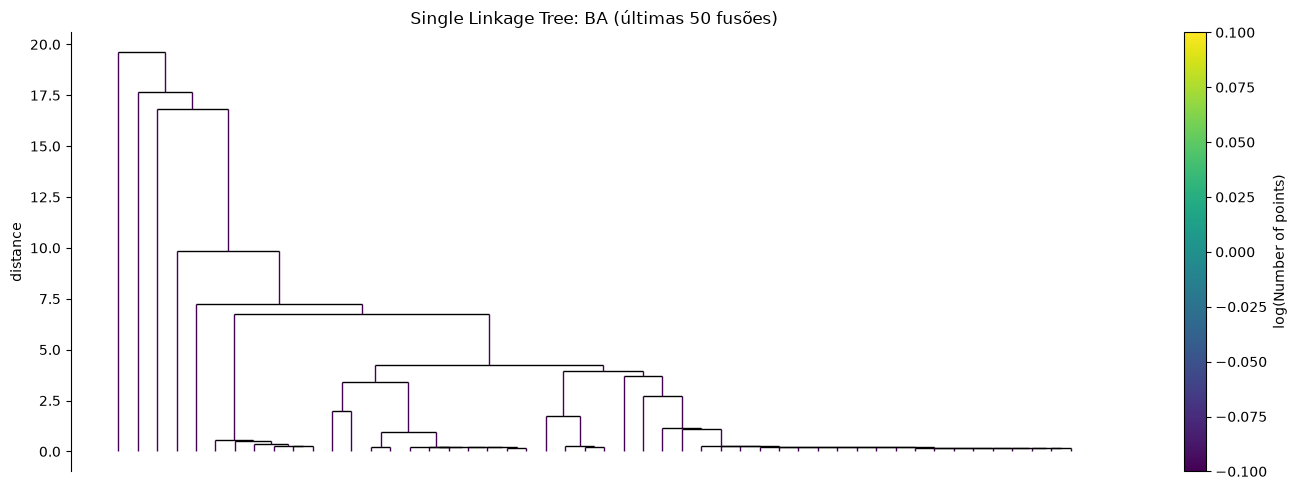

In [4]:
# Single Linkage Tree: vary_line_width=False evita RecursionError em datasets grandes
fig, ax = plt.subplots(figsize=(14, 5))
clusterer.single_linkage_tree_.plot(
    truncate_mode='lastp', p=50,
    vary_line_width=False,
    cmap='viridis', colorbar=True, axis=ax
)
ax.set_title('Single Linkage Tree: BA (últimas 50 fusões)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/single_linkage_tree_ba.png', dpi=150)
plt.show()

In [5]:
# Silhouette nos dois espaços: diagnóstico metodológico
mask = df['cluster'] != -1
score_umap = silhouette_score(X_umap[mask], df.loc[mask, 'cluster'],
                              sample_size=10000, random_state=42)
score_11d  = silhouette_score(X[mask], df.loc[mask, 'cluster'],
                              sample_size=10000, random_state=42)

print(f'Silhouette UMAP (2D) : {score_umap:.4f}')
print(f'Silhouette 11D       : {score_11d:.4f}')
print()
print('Por que o score 11D pode ser negativo?')
print('UMAP com min_dist=0.0 cria clusters baseados em vizinhança topológica.')
print('Dois pontos vizinhos em UMAP podem não ser próximos em distância 11D')
print('(estão conectados por uma cadeia de vizinhos, não diretamente).')
print('O silhouette em 11D mede distância euclidiana; logo, clusters formados')
print('por topologia podem se sobrepor em 11D e gerar score negativo.')
print()
print('Trade-off:')
print('  11D direto   → clusters semanticamente puros, mas 89% de ruído')
print('  UMAP→HDBSCAN → 0.3% de ruído, cobertura total, score em espaço UMAP')

Silhouette UMAP (2D) : 0.3078
Silhouette 11D       : -0.0989

Por que o score 11D pode ser negativo?
UMAP com min_dist=0.0 cria clusters baseados em vizinhança topológica.
Dois pontos vizinhos em UMAP podem não ser próximos em distância 11D
(estão conectados por uma cadeia de vizinhos, não diretamente).
O silhouette em 11D mede distância euclidiana; logo, clusters formados
por topologia podem se sobrepor em 11D e gerar score negativo.

Trade-off:
  11D direto   → clusters semanticamente puros, mas 89% de ruído
  UMAP→HDBSCAN → 0.3% de ruído, cobertura total, score em espaço UMAP


In [6]:
# Nomenclatura semântica por cluster individual
# Baseada no perfil completo de z-scores, não apenas na feature dominante

NOMES_CLUSTER = {
    0:  'Residencial Puro (núcleo A)',
    1:  'Residencial Puro (núcleo B)',
    2:  'Residencial Puro (núcleo C)',
    3:  'Residencial Puro (núcleo D)',
    4:  'Residencial Puro',
    5:  'Residencial Denso',
    6:  'Rural / Peri-urbano Misto',
    7:  'Residencial c/ Educacional',
    8:  'Uso Misto Comercial',
    9:  'Rural (baixa densidade)',
    10: 'Rural Agrícola',
    11: 'Domicílio Coletivo (Institucional)',
    12: 'Setor Urbano Típico',
}

# tipo semântico agrupado (para mapas e análise de alto nível)
TIPO_CLUSTER = {
    0:  'Residencial Puro',
    1:  'Residencial Puro',
    2:  'Residencial Puro',
    3:  'Residencial Puro',
    4:  'Residencial Puro',
    5:  'Residencial Denso',
    6:  'Rural / Peri-urbano',
    7:  'Residencial c/ Educacional',
    8:  'Uso Misto Comercial',
    9:  'Rural',
    10: 'Rural Agrícola',
    11: 'Domicílio Coletivo',
    12: 'Setor Urbano Típico',
}

df['cluster_nome']  = df['cluster'].map(lambda x: NOMES_CLUSTER.get(x, 'Ruído') if x != -1 else 'Ruído')
df['cluster_tipo']  = df['cluster'].map(lambda x: TIPO_CLUSTER.get(x, 'Ruído')  if x != -1 else 'Ruído')

print('─' * 70)
print(f'{"Cluster":>8}  {"Nome semântico":<42} {"n":>6}  {"tipo agrupado"}')
print('─' * 70)
for cid in sorted(NOMES_CLUSTER):
    n = (df['cluster'] == cid).sum()
    print(f'{cid:>8}  {NOMES_CLUSTER[cid]:<42} {n:>6,}  {TIPO_CLUSTER[cid]}')

print()
print('Nota: clusters 0–3 têm z-scores IDÊNTICOS em todas as features.')
print('O UMAP os separou por serem núcleos residenciais em CIDADES DISTINTAS da BA.')
print('São o mesmo tipo semântico em localizações geográficas diferentes.')

──────────────────────────────────────────────────────────────────────
 Cluster  Nome semântico                                  n  tipo agrupado
──────────────────────────────────────────────────────────────────────
       0  Residencial Puro (núcleo A)                   114  Residencial Puro
       1  Residencial Puro (núcleo B)                    96  Residencial Puro
       2  Residencial Puro (núcleo C)                   112  Residencial Puro
       3  Residencial Puro (núcleo D)                   107  Residencial Puro
       4  Residencial Puro                              291  Residencial Puro
       5  Residencial Denso                           1,305  Residencial Denso
       6  Rural / Peri-urbano Misto                     246  Rural / Peri-urbano
       7  Residencial c/ Educacional                     94  Residencial c/ Educacional
       8  Uso Misto Comercial                         2,649  Uso Misto Comercial
       9  Rural (baixa densidade)                        97  Rur

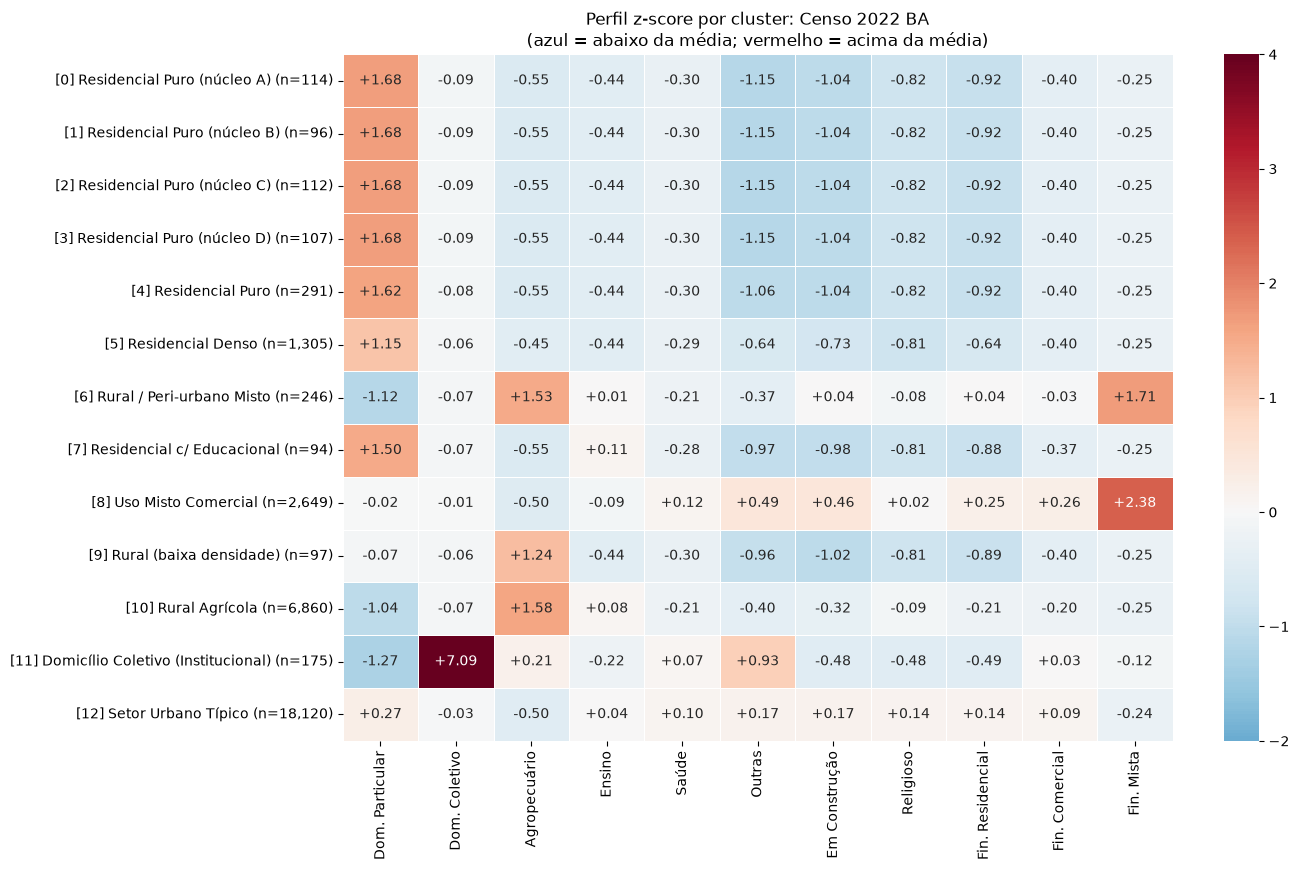

In [7]:
# Heatmap: z-score médio de cada um dos 13 clusters individuais
FEATURES_LABEL = {
    'prop_domicilio_particular':  'Dom. Particular',
    'prop_domicilio_coletivo':    'Dom. Coletivo',
    'prop_estab_agropecuario':    'Agropecuário',
    'prop_estab_ensino':          'Ensino',
    'prop_estab_saude':           'Saúde',
    'prop_estab_outras':          'Outras',
    'prop_construcao':            'Em Construção',
    'prop_estab_religioso':       'Religioso',
    'prop_finalidade_residencial':'Fin. Residencial',
    'prop_finalidade_comercial':  'Fin. Comercial',
    'prop_finalidade_mista':      'Fin. Mista',
}

df_cl = df[df['cluster'] != -1].copy()

perfil = (df_cl.groupby('cluster')[FEATURES].mean()
               .rename(columns=FEATURES_LABEL))
tamanhos = df_cl.groupby('cluster').size()
perfil.index = [f'[{i}] {NOMES_CLUSTER[i]} (n={tamanhos[i]:,})' for i in perfil.index]

fig, ax = plt.subplots(figsize=(14, max(5, len(perfil) * 0.6 + 1)))
sns.heatmap(perfil, annot=True, fmt='+.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-2, vmax=4)
ax.set_title('Perfil z-score por cluster: Censo 2022 BA\n'
             '(azul = abaixo da média; vermelho = acima da média)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/perfil_clusters_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

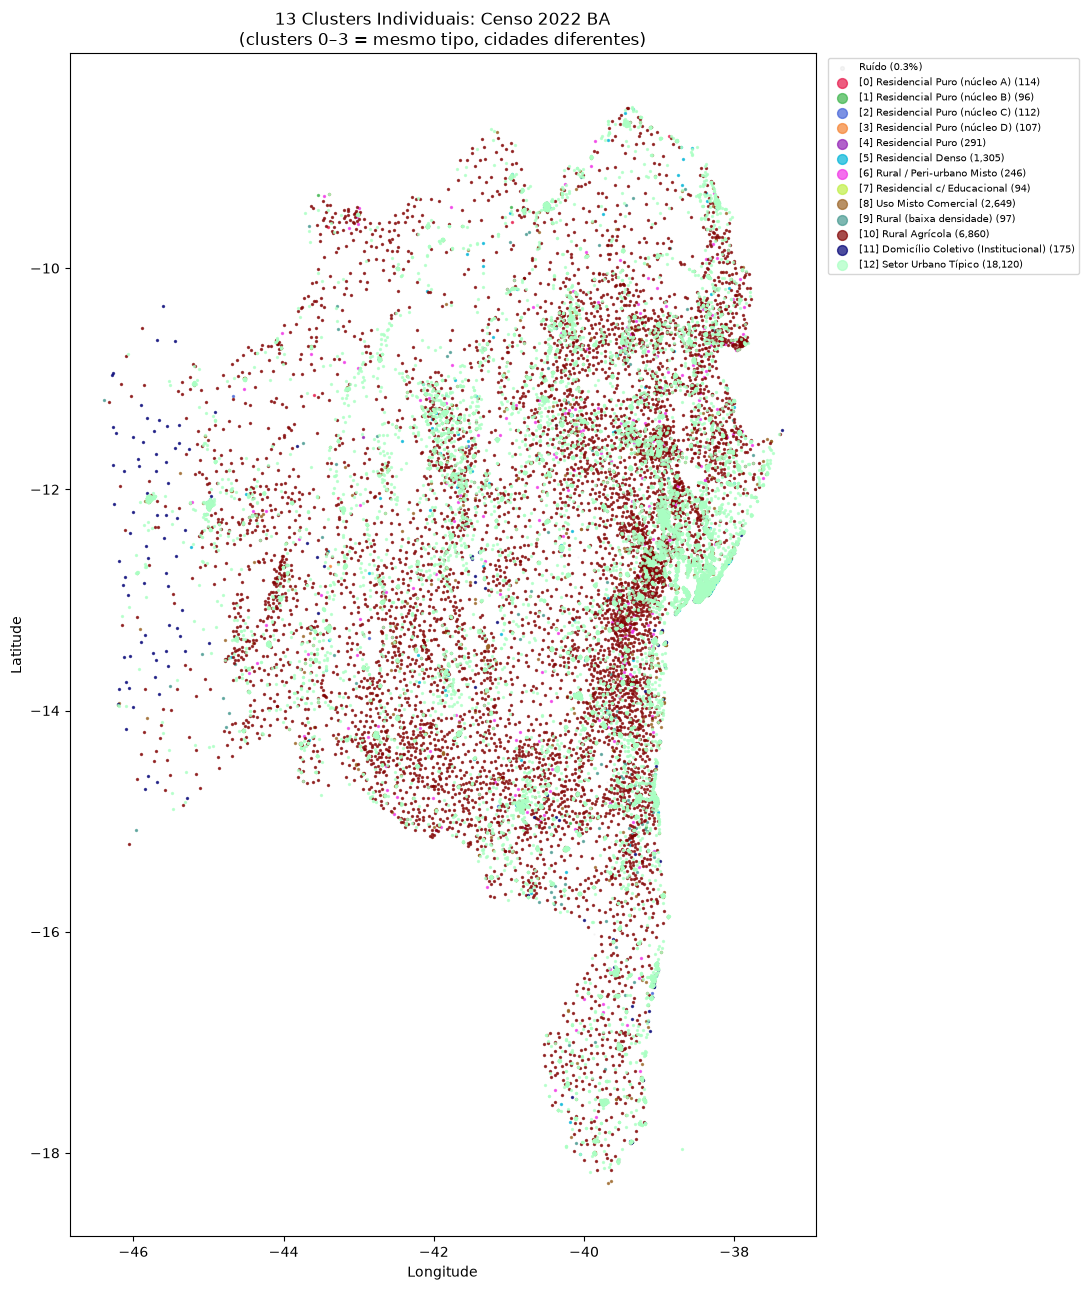

In [8]:
# Mapa geográfico: 13 clusters individuais
# Revela que clusters 0-3 são núcleos residenciais em cidades diferentes
CORES = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
         '#00b4d8','#f032e6','#bfef45','#9A6324','#469990',
         '#800000','#000075','#aaffc3']

fig, ax = plt.subplots(figsize=(11, 13))
noise = df[df['cluster'] == -1]
ax.scatter(noise['lon_centroide'], noise['lat_centroide'],
           s=0.3, c='#cccccc', alpha=0.2, label='Ruído (0.3%)')

for cid in sorted(NOMES_CLUSTER):
    sub = df[df['cluster'] == cid]
    ax.scatter(sub['lon_centroide'], sub['lat_centroide'],
               s=2, alpha=0.7, color=CORES[cid % len(CORES)],
               label=f'[{cid}] {NOMES_CLUSTER[cid]} ({len(sub):,})')

ax.legend(markerscale=5, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
ax.set_title('13 Clusters Individuais: Censo 2022 BA\n'
             '(clusters 0–3 = mesmo tipo, cidades diferentes)', fontsize=12)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/clusters_mapa_13_individuais.png', dpi=150, bbox_inches='tight')
plt.show()

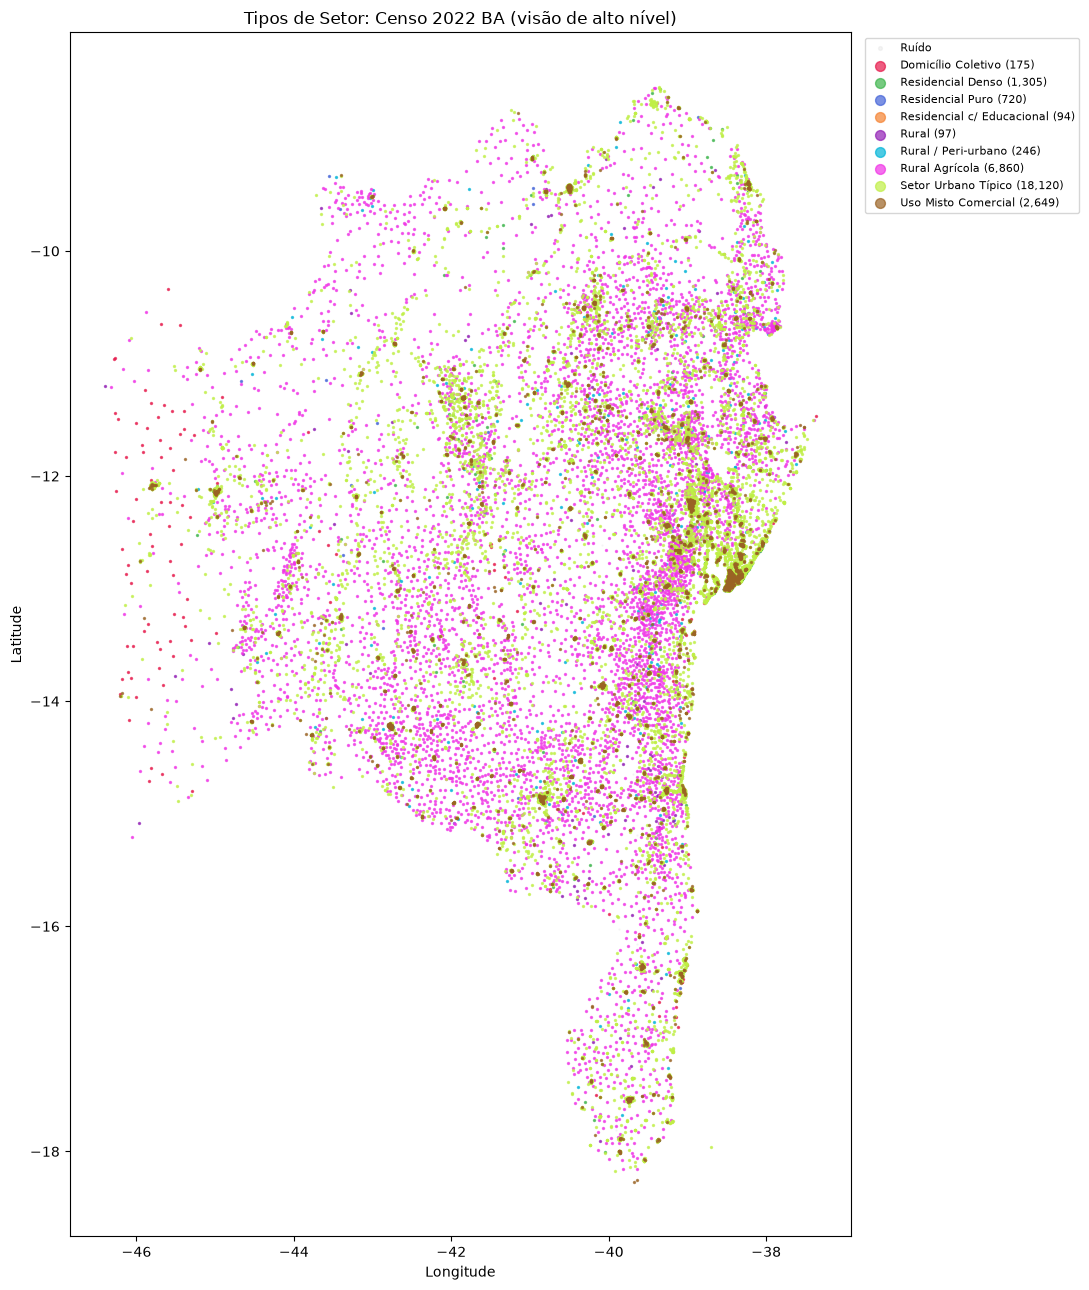

In [9]:
# Mapa geográfico: tipos agrupados (visão de alto nível)
CORES_FORTES = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
                '#00b4d8','#f032e6','#bfef45','#9A6324','#469990',
                '#800000','#000075','#ff6b6b']

tipos_unicos = sorted(df[df['cluster'] != -1]['cluster_tipo'].unique())
palette_tipo = {t: CORES_FORTES[i % len(CORES_FORTES)] for i, t in enumerate(tipos_unicos)}

fig, ax = plt.subplots(figsize=(11, 13))
noise = df[df['cluster'] == -1]
ax.scatter(noise['lon_centroide'], noise['lat_centroide'],
           s=0.3, c='#cccccc', alpha=0.2, label='Ruído')

for tipo in tipos_unicos:
    sub = df[df['cluster_tipo'] == tipo]
    n = len(sub)
    ax.scatter(sub['lon_centroide'], sub['lat_centroide'],
               s=2, alpha=0.7, color=palette_tipo[tipo],
               label=f'{tipo} ({n:,})')

ax.legend(markerscale=5, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_title('Tipos de Setor: Censo 2022 BA (visão de alto nível)', fontsize=12)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/clusters_mapa_tipos.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Salvar resultado com cluster atribuído
df.to_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet', index=False)
print(f'Salvo: outputs/setores_clusterizados.parquet')

Salvo: outputs/setores_clusterizados.parquet
